In [1]:
import kagglehub

# Download latest version
data1 = kagglehub.dataset_download("kabure/german-credit-data-with-risk")
data2 = kagglehub.dataset_download("mishra5001/credit-card")


In [2]:
import pandas as pd
df1=pd.read_csv(data1+"/german_credit_data.csv")
df2=pd.read_csv(data2+"/application_data.csv")


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

In [3]:
df1.head()
df1 = df1.drop(columns=['Unnamed: 0'])
df1.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
df1["Age"].value_counts()
df1["Sex"].value_counts()
df1["Housing"].value_counts()
df1["Saving accounts"].value_counts()
df1["Checking account"].value_counts()
df1["Purpose"].value_counts()
df1.dtypes

df1.isnull().sum()

df1_missing=["Saving accounts","Checking account"]

df1[df1_missing] = df1[df1_missing].fillna(df1[df1_missing].mode().iloc[0])


In [5]:
print(df2.shape)
df2.dtypes
df2.isnull().sum()
df2.columns
df2.head()
df2["TARGET"].value_counts()
selected_columns = [
    "TARGET","CODE_GENDER",
    "CNT_CHILDREN","CNT_FAM_MEMBERS",
    "NAME_FAMILY_STATUS",
    "NAME_EDUCATION_TYPE",
    "DAYS_BIRTH","AMT_INCOME_TOTAL",
    "AMT_CREDIT","AMT_ANNUITY",
    "AMT_GOODS_PRICE","NAME_INCOME_TYPE",
    "NAME_CONTRACT_TYPE",
   "NAME_HOUSING_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

df2[selected_columns].isnull().sum()


df2['CNT_FAM_MEMBERS'] = df2['CNT_FAM_MEMBERS'].fillna(df2['CNT_FAM_MEMBERS'].median())

df2['AMT_ANNUITY'] = df2['AMT_ANNUITY'].fillna(df2['AMT_ANNUITY'].median())

df2['AMT_GOODS_PRICE'] = df2['AMT_GOODS_PRICE'].fillna(df2['AMT_GOODS_PRICE'].median())

df2[selected_columns].isnull().sum()



(307511, 122)


TARGET                 0
CODE_GENDER            0
CNT_CHILDREN           0
CNT_FAM_MEMBERS        0
NAME_FAMILY_STATUS     0
NAME_EDUCATION_TYPE    0
DAYS_BIRTH             0
AMT_INCOME_TOTAL       0
AMT_CREDIT             0
AMT_ANNUITY            0
AMT_GOODS_PRICE        0
NAME_INCOME_TYPE       0
NAME_CONTRACT_TYPE     0
NAME_HOUSING_TYPE      0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
dtype: int64

In [6]:
df2_clean=df2[selected_columns]
df2_clean.dtypes
# for col in selected_columns:
#     print(df2_clean[col].value_counts())

df2_clean = df2_clean[df2_clean['CODE_GENDER'].isin(['M', 'F'])]
df2_clean = df2_clean[df2_clean['CNT_CHILDREN'].isin([1,2,3,4,5])]
df2_clean = df2_clean[df2_clean['CNT_FAM_MEMBERS'].isin([1,2,3,4,5,6,7,8])]
df2_clean = df2_clean[~df2_clean['NAME_FAMILY_STATUS'].isin(['unknown'])]
df2_clean = df2_clean[~df2_clean['NAME_FAMILY_STATUS'].isin(['unknown'])]

for col in selected_columns:
    print(df2_clean[col].value_counts())



TARGET
0    83889
1     8207
Name: count, dtype: int64
CODE_GENDER
F    57374
M    34722
Name: count, dtype: int64
CNT_CHILDREN
1    61118
2    26748
3     3717
4      429
5       84
Name: count, dtype: int64
CNT_FAM_MEMBERS
3.0    52600
4.0    24696
2.0    10835
5.0     3478
6.0      408
7.0       79
Name: count, dtype: int64
NAME_FAMILY_STATUS
Married                 69824
Civil marriage           8824
Single / not married     6631
Separated                5636
Widow                    1181
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    62512
Higher education                 25242
Incomplete higher                 3388
Lower secondary                    911
Academic degree                     43
Name: count, dtype: int64
DAYS_BIRTH
-13891    30
-13481    29
-14384    27
-13816    26
-13379    26
          ..
-17079     1
-17278     1
-7966      1
-18983     1
-21764     1
Name: count, Length: 12739, dtype: int64
AMT_INCOME_TOTAL
135000.0    11050
11250

In [ ]:

def find_best_k(X_train, y_train, k_range=range(1, 21), scoring='accuracy', cv=10):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    k_scores = []
    for k in k_range:
        KNN = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(KNN, X_train_scaled, y_train, cv=skf, scoring=scoring, n_jobs=-1)
        k_scores.append({'k': k, f'{scoring}_mean': scores.mean(), f'{scoring}_std': scores.std()})
        print(f"k={k}: {scoring}={scores.mean():.4f} (+/- {scores.std():.4f})")

    results_df = pd.DataFrame(k_scores)
    best_row = results_df.loc[results_df[f'{scoring}_mean'].idxmax()]
    best_k = int(best_row['k'])

    print(f"\n Best k  is {best_k}")


    plt.figure(figsize=(8, 5))
    plt.plot(results_df['k'], results_df[f'{scoring}_mean'], marker='o')
    plt.xlabel('k (number of neighbours)')
    plt.ylabel(f'Mean {scoring} (CV)')
    plt.title(f'KNN: {scoring} vs k')
    plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.legend()
    plt.grid(True)
    plt.savefig('best_k_plot.png', dpi=100, bbox_inches='tight')
    plt.show()

    return best_k, results_df




def prepare_and_split(df, target_col, test_size=0.2, random_state=42):
    
    df = df.copy()

    if df[target_col].dtype == 'object':
        df[target_col] = df[target_col].map({'good': 0, 'bad': 1}) 

    y = df[target_col]
    X = df.drop(columns=[target_col])

    X = pd.get_dummies(X, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test

def train_and_evaluate(X_train, X_test, y_train, y_test, dataset_name="", k=3):
    """Train Logistic Regression and KNN, print evaluation metrics."""
    results = {}

    # scaling features in both models 
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # --- Logistic Regression ---
    log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
    log_reg.fit(X_train_scaled, y_train)
    y_pred_lr = log_reg.predict(X_test_scaled)
    y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

    results['Logistic Regression'] = {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'precision': precision_score(y_test, y_pred_lr),
        'recall': recall_score(y_test, y_pred_lr),
        'f1': f1_score(y_test, y_pred_lr),
    }

    # KNN
    KNN = KNeighborsClassifier(n_neighbors=k)
    KNN.fit(X_train_scaled, y_train)
    y_pred_KNN = KNN.predict(X_test_scaled)
    y_proba_KNN = KNN.predict_proba(X_test_scaled)[:, 1]

    results['KNN'] = {
        'accuracy': accuracy_score(y_test, y_pred_KNN),
        'precision': precision_score(y_test, y_pred_KNN),
        'recall': recall_score(y_test, y_pred_KNN),
        'f1': f1_score(y_test, y_pred_KNN),
    }

    print(f"\n{'='*20} {dataset_name} RESULTS {'='*20}")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        for metric_name, value in metrics.items():
            print(f"  {metric_name}: {value:.4f}")

    return results, log_reg, KNN

In [8]:

X_train1, X_test1, y_train1, y_test1 = prepare_and_split(df1, target_col='Risk')

X_train2, X_test2, y_train2, y_test2 = prepare_and_split(df2_clean, target_col='TARGET')


k=1: f1=0.3743 (+/- 0.0718)
k=2: f1=0.1818 (+/- 0.0725)
k=3: f1=0.3111 (+/- 0.0345)
k=4: f1=0.1456 (+/- 0.0898)
k=5: f1=0.2392 (+/- 0.0541)
k=6: f1=0.1054 (+/- 0.0677)
k=7: f1=0.1999 (+/- 0.0495)
k=8: f1=0.1038 (+/- 0.0626)
k=9: f1=0.1344 (+/- 0.0756)
k=10: f1=0.0703 (+/- 0.0536)
k=11: f1=0.1348 (+/- 0.0727)
k=12: f1=0.0850 (+/- 0.0582)
k=13: f1=0.1421 (+/- 0.0482)
k=14: f1=0.0690 (+/- 0.0613)
k=15: f1=0.1304 (+/- 0.0801)
k=16: f1=0.0716 (+/- 0.0535)
k=17: f1=0.1087 (+/- 0.0713)
k=18: f1=0.0516 (+/- 0.0728)
k=19: f1=0.0901 (+/- 0.0588)
k=20: f1=0.0517 (+/- 0.0572)

 Best k  is 1


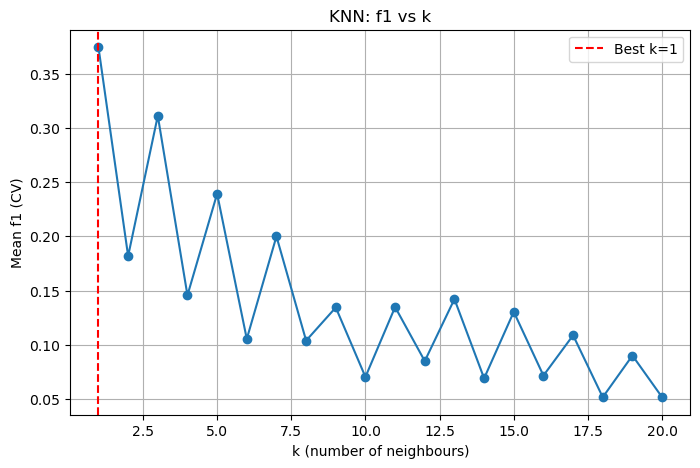

In [11]:
# German Credit
best_k1, scores_df1 = find_best_k(X_train1, y_train1, k_range=range(1, 21), scoring='f1')

# Home Credit — note: with 92K rows this may take a while, consider k_range=range(1, 15)
#best_k2, scores_df2 = find_best_k(X_train2, y_train2, k_range=range(1, 21), scoring='f1')

In [12]:

results1, lr1, knn1 = train_and_evaluate(X_train1, X_test1, y_train1, y_test1, "German Credit")


results2, lr2, knn2 = train_and_evaluate(X_train2, X_test2, y_train2, y_test2, "Home Credit")





==================== German Credit RESULTS ====================

Logistic Regression:
  accuracy: 0.6150
  precision: 0.3976
  recall: 0.5500
  f1: 0.4615

KNN:
  accuracy: 0.6550
  precision: 0.3902
  recall: 0.2667
  f1: 0.3168

==================== Home Credit RESULTS ====================

Logistic Regression:
  accuracy: 0.5720
  precision: 0.1238
  recall: 0.6258
  f1: 0.2067

KNN:
  accuracy: 0.8913
  precision: 0.1291
  recall: 0.0384
  f1: 0.0592


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams.update({'font.size': 12})

def plot_metric_comparison(results_dict, dataset_name, save_path=None):
    """results_dict: {'Logistic Regression': {...metrics...}, 'kNN': {...metrics...}}"""
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    models = list(results_dict.keys())
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    for i, model in enumerate(models):
        values = [results_dict[model][m] for m in metrics]
        ax.bar(x + i*width, values, width, label=model)

    ax.set_xticks(x + width/2)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.set_title(f'Model Comparison — {dataset_name}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_class_balance(y, dataset_name, save_path=None):
    counts = y.value_counts().sort_index()
    labels = ['No Default', 'Default'] if len(counts) == 2 else counts.index.tolist()
    fig, ax = plt.subplots(figsize=(6, 5))
    bars = ax.bar(labels, counts.values, color=['#4C72B0', '#DD8452'])
    for bar, val in zip(bars, counts.values):
        pct = val / counts.sum() * 100
        ax.text(bar.get_x() + bar.get_width()/2, val, f'({pct:.1f}%)',
                ha='center', va='bottom', fontsize=11)
    ax.set_ylabel('Count')
    ax.set_title(f'Class Balance — {dataset_name}')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

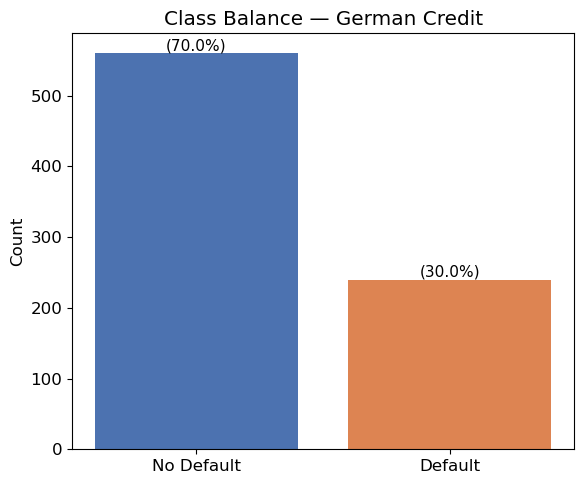

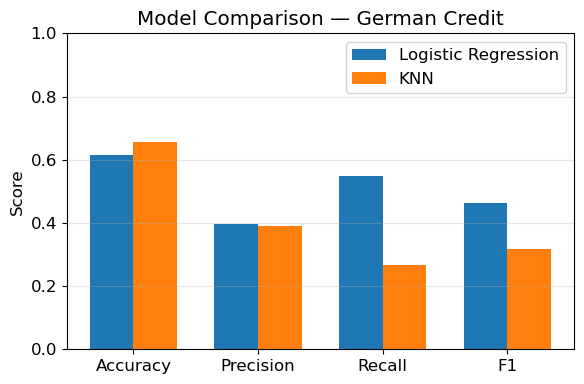

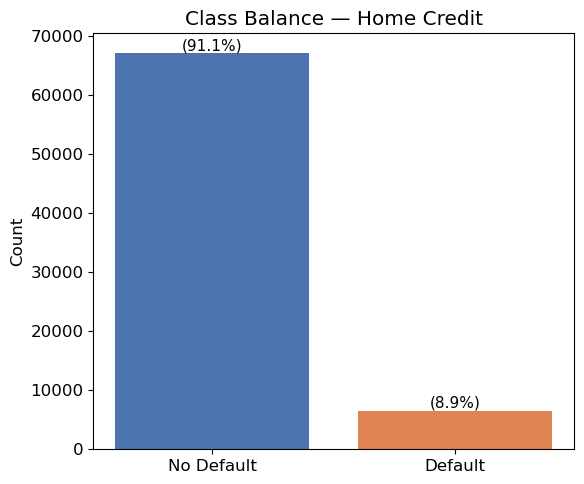

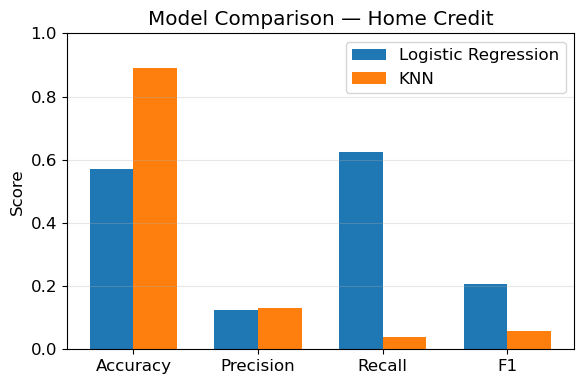

In [14]:
# German Credit
plot_class_balance(y_train1, "German Credit", save_path="german_class_balance.png")
plot_metric_comparison(results1, "German Credit", save_path="german_metrics.png")

scaler = StandardScaler()
X_train1_scaled = scaler.fit_transform(X_train1)
X_test1_scaled = scaler.transform(X_test1)

# Home Credit — same pattern
plot_class_balance(y_train2, "Home Credit", save_path="home_class_balance.png")
plot_metric_comparison(results2, "Home Credit", save_path="home_metrics.png")
# ... etc